In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score)

from imblearn.over_sampling import SMOTE

# modeling
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

# EDA

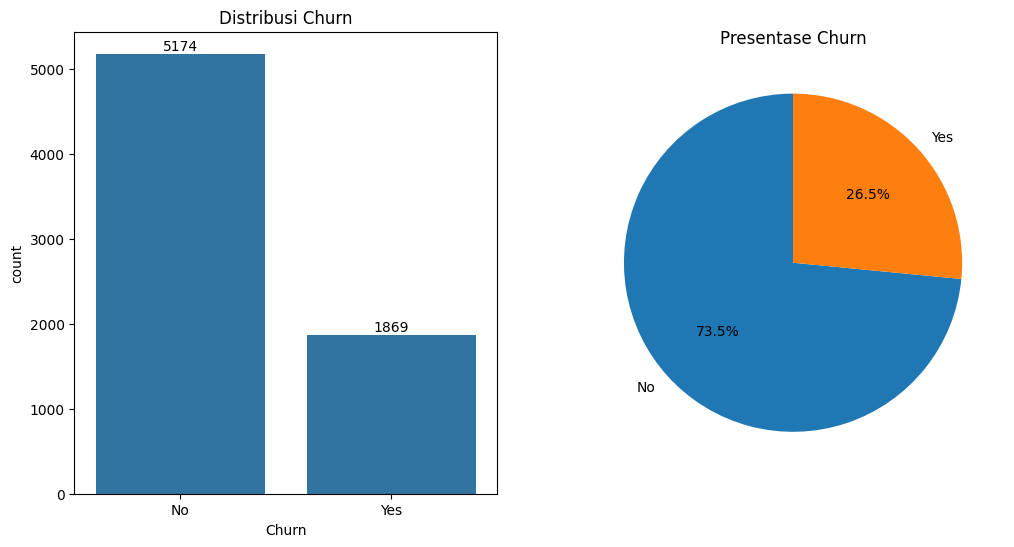

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# Distribusi Churn dan presentasenya 
ax = sns.countplot(data=df, x='Churn', ax=axes[0])
for i in axes[0].containers:
    axes[0].bar_label(i)
axes[0].set_title('Distribusi Churn')

count_churn = df['Churn'].value_counts()
axes[1].pie(count_churn, labels=count_churn.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Presentase Churn')

plt.savefig('1.Churn Class Distribution.png', dpi=150, bbox_inches='tight')
plt.show()

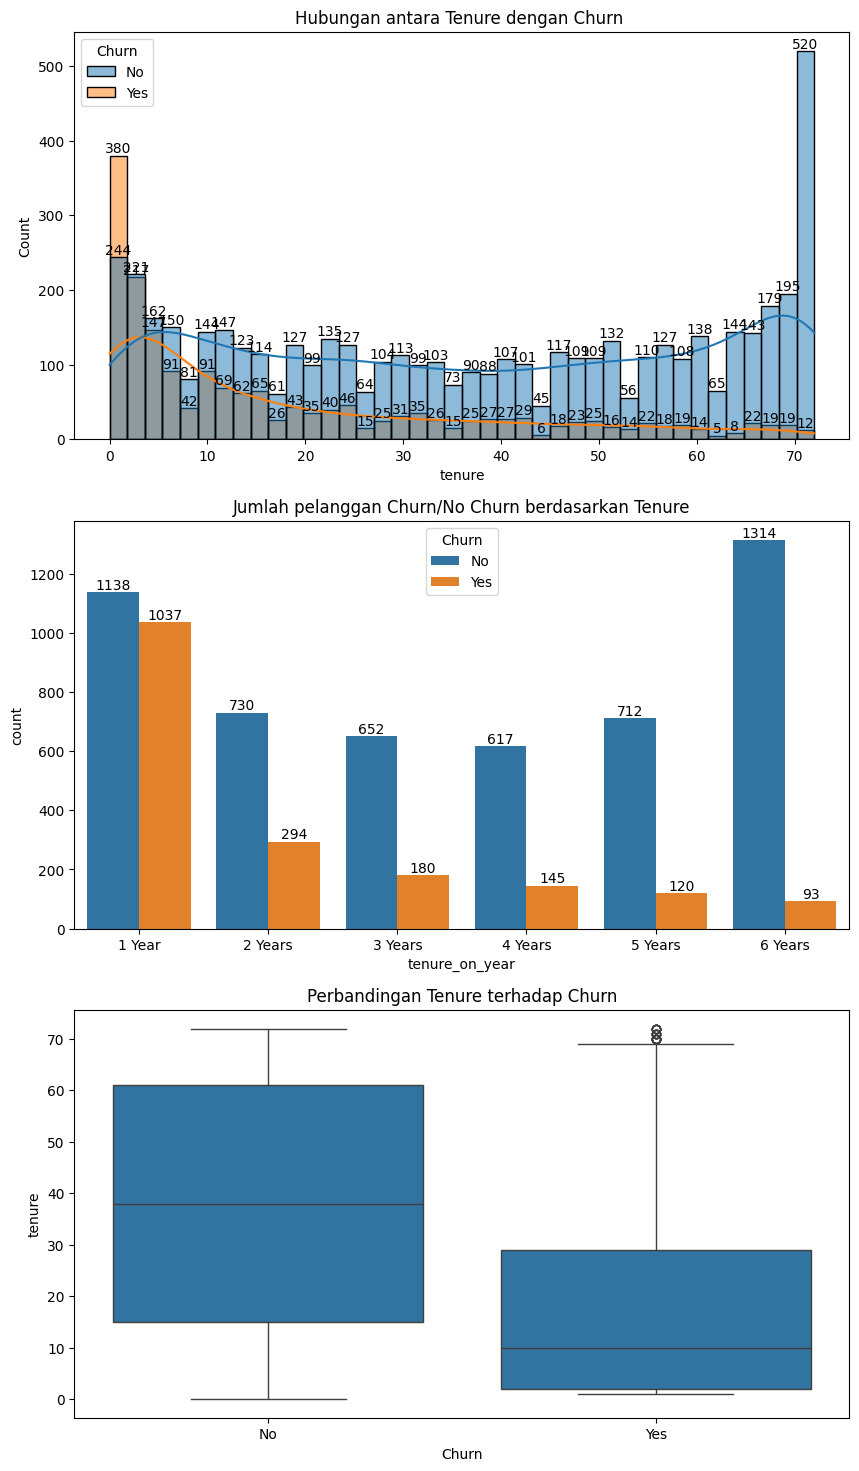

In [6]:
# hubungan tenure(lama berlangganan) dengan churn
fig, axes = plt.subplots(3,1, figsize=(10, 18))

# tenure vs churn
sns.histplot(data=df, x='tenure', hue='Churn', bins=40, kde=True, ax=axes[0])
for i in axes[0].containers:
    axes[0].bar_label(i)
axes[0].set_title('Hubungan antara Tenure dengan Churn ')

# melihat jumlah banyaknya pelanggan churn atau tidak dalam tahunan
df['tenure_on_year'] = pd.cut(df['tenure'], bins=(0,12,24,36,48,60,72),
                           labels=['1 Year','2 Years','3 Years','4 Years','5 Years','6 Years'])
sns.countplot(data=df, x='tenure_on_year', hue='Churn',ax=axes[1])
for i in axes[1].containers:
    axes[1].bar_label(i)
axes[1].set_title('Jumlah pelanggan Churn/No Churn berdasarkan Tenure')

# hubungan tenure dengan chuen dalam bentuk boxplot=
sns.boxplot(data=df, x='Churn', y='tenure')
axes[2].set_title('Perbandingan Tenure terhadap Churn')

plt.savefig('2.Tenure vs Churn.png', dpi=150, bbox_inches='tight')
plt.show()

Visualisasi menunjukkan bahwa pelanggan dengan tenure rendah (awal berlangganan) memiliki jumlah churn yang jauh lebih tinggi dibandingkan pelanggan dengan tenure yang lebih lama. Hal ini terlihat baik dari distribusi maupun agregasi per tahun, di mana churn paling banyak terjadi pada tahun pertama dan terus menurun seiring bertambahnya lama berlangganan. Pola ini mengindikasikan bahwa pelanggan baru merupakan kelompok yang paling rentan untuk berhenti.

Boxplot juga memperkuat temuan tersebut, di mana median tenure pelanggan yang churn jauh lebih rendah dibandingkan yang tidak churn. Pelanggan yang tidak churn cenderung memiliki tenure yang lebih tinggi dan distribusi yang lebih luas, menunjukkan tingkat loyalitas yang lebih kuat. Dengan demikian, dapat disimpulkan bahwa tenure merupakan faktor penting dalam churn, di mana semakin lama pelanggan berlangganan, semakin kecil kemungkinan mereka untuk berhenti.

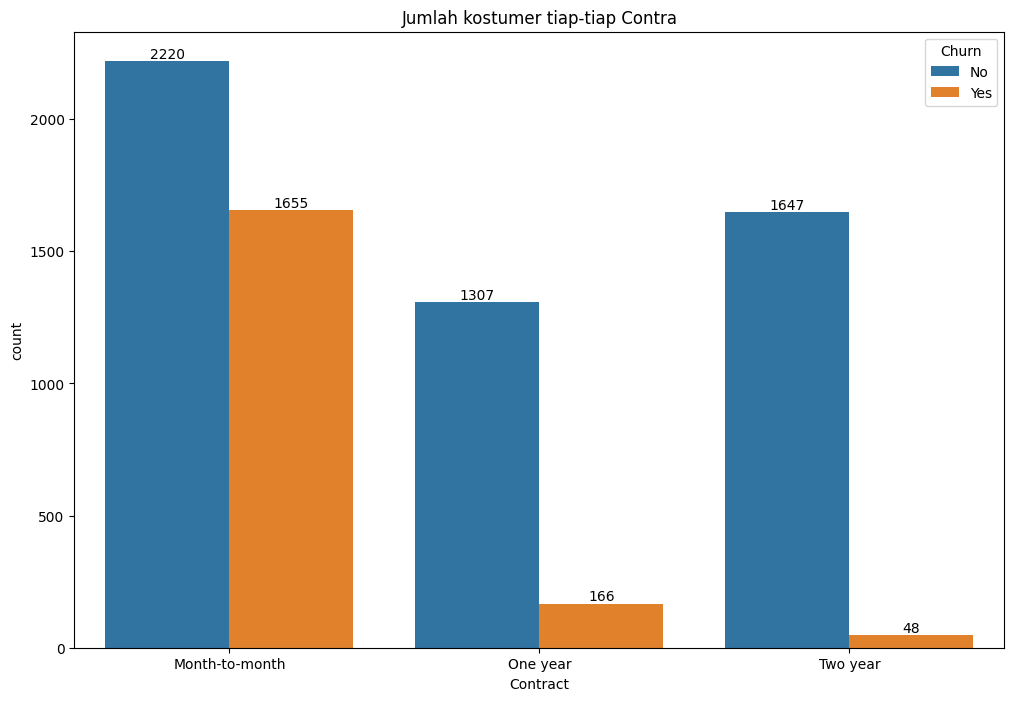

In [7]:
# Contrac dengan Churn
# biasana kalo contraknya dalam tahunan kemungkinan besar Churnnya kecil

plt.figure(figsize=(12,8))
ax=sns.countplot(data=df, x='Contract', hue='Churn')
for i in ax.containers:
    ax.bar_label(i)
plt.title('Jumlah kostumer tiap-tiap Contra')

plt.savefig('3.Contract vs Churn.png', dpi=150, bbox_inches='tight')
plt.show()

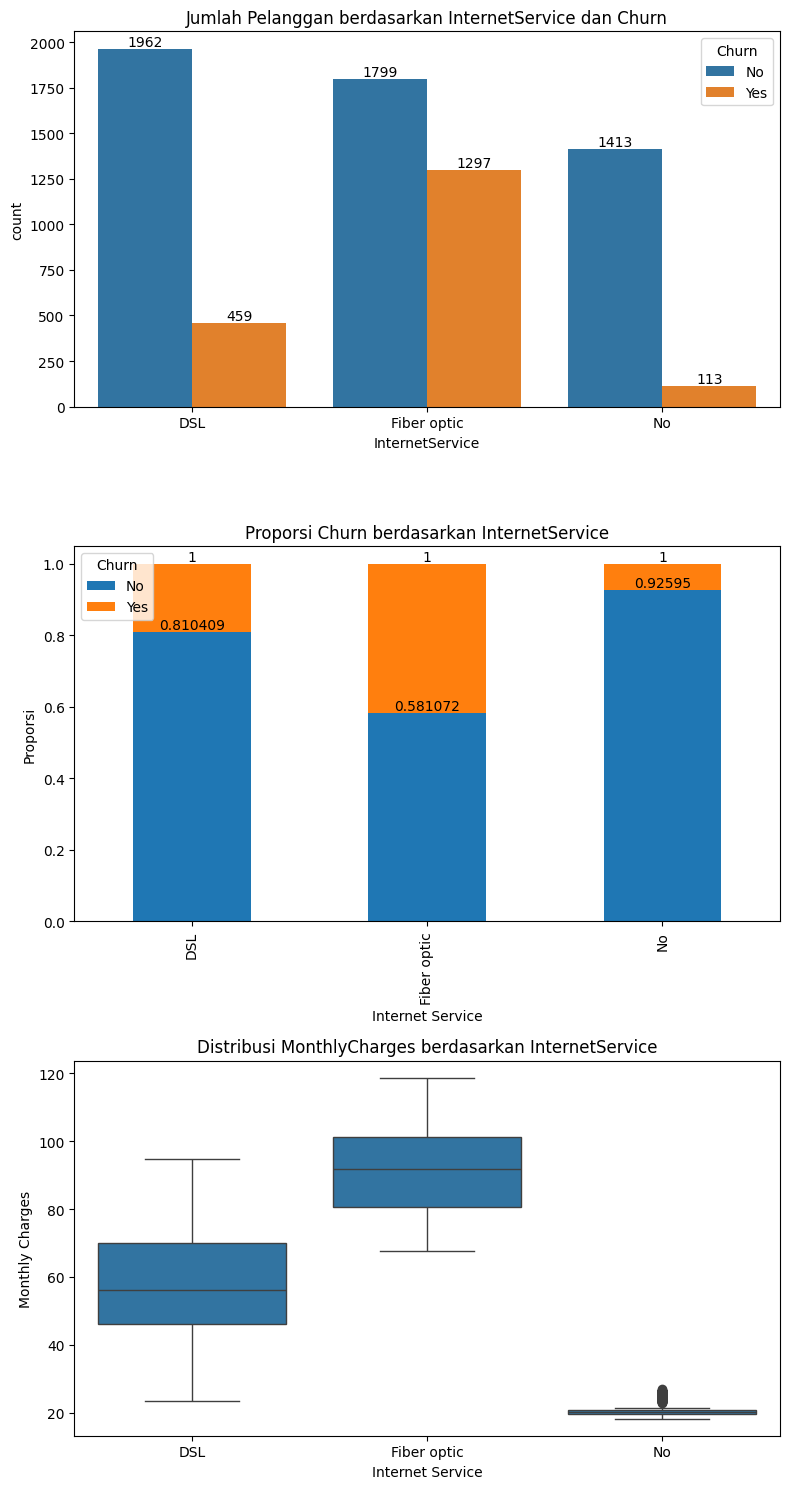

In [8]:
# Visualisasi InternetService

# countplot
fig, axes = plt.subplots(3,1, figsize=(8,15))
sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[0])
for i in axes[0].containers:
    axes[0].bar_label(i)
axes[0].set_title('Jumlah Pelanggan berdasarkan InternetService dan Churn')

# Proporsi Churn
ct = pd.crosstab(df['InternetService'], df['Churn'], normalize='index')
ct.plot(kind='bar', stacked=True, ax=axes[1])
for i in axes[1].containers:
    axes[1].bar_label(i)
axes[1].set_title('Proporsi Churn berdasarkan InternetService')
axes[1].set_xlabel('Internet Service')
axes[1].set_ylabel('Proporsi')

#  boxplot MonthlyCharges
sns.boxplot(data=df, x='InternetService', y='MonthlyCharges', ax=axes[2])
axes[2].set_title('Distribusi MonthlyCharges berdasarkan InternetService')
axes[2].set_xlabel('Internet Service')
axes[2].set_ylabel('Monthly Charges')

plt.tight_layout()
plt.savefig('4.InternetService vs Churn.png', dpi=150, bbox_inches='tight')
plt.show()

Visualisasi menunjukkan bahwa pelanggan dengan layanan Fiber optic memiliki jumlah dan proporsi churn yang paling tinggi dibandingkan DSL dan tanpa internet. Meskipun jumlah pelanggan Fiber optic cukup besar, tingkat churn-nya juga signifikan, yang mengindikasikan bahwa segmen ini lebih rentan untuk berhenti berlangganan. Sebaliknya, pelanggan tanpa internet memiliki tingkat churn paling rendah, menunjukkan kecenderungan yang lebih stabil.

Dari sisi biaya, boxplot memperlihatkan bahwa Fiber optic memiliki MonthlyCharges paling tinggi, diikuti DSL, dan terendah pada pelanggan tanpa internet. Hal ini menguatkan indikasi bahwa biaya layanan yang lebih tinggi dapat menjadi faktor pendorong churn, terutama pada pengguna Fiber optic yang kemungkinan memiliki ekspektasi layanan lebih tinggi.

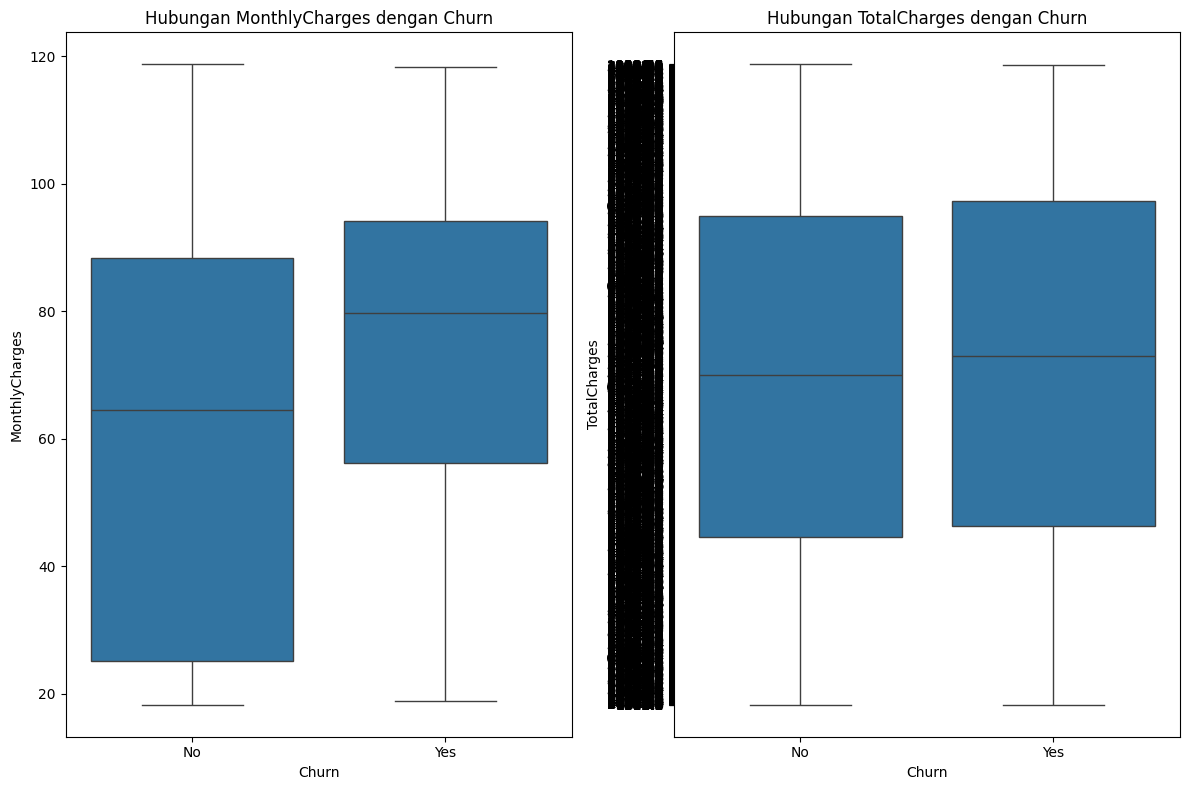

In [9]:
# MonthlyCharges dan TotalCharges dengan Churn 
fig, axes = plt.subplots(1,2, figsize=(12,8))

# MonthlyCharges vs Churn
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[0])
axes[0].set_title('Hubungan MonthlyCharges dengan Churn')

# TotalCharges vs Churn
sns.boxplot(data=df, x='Churn', y='TotalCharges', ax=axes[1])
axes[1].set_title('Hubungan TotalCharges dengan Churn')

plt.tight_layout()
plt.savefig('5.MonthlyCharges and TotalCharges vs Churn.png', dpi=150, bbox_inches='tight')
plt.show()

Visualisasi menunjukkan bahwa pada MonthlyCharges, pelanggan yang melakukan churn memiliki median biaya yang lebih tinggi dibandingkan pelanggan yang tidak churn. Hal ini mengindikasikan bahwa biaya bulanan yang besar berpotensi meningkatkan kemungkinan pelanggan untuk berhenti berlangganan. Sementara itu, pada TotalCharges, pola yang terlihat belum memberikan perbedaan yang jelas antara kelompok churn dan non-churn, sehingga interpretasinya masih terbatas dan belum dapat dijadikan dasar kesimpulan yang kuat.

Perlu diperhatikan bahwa variabel TotalCharges masih bertipe object (string), sehingga visualisasi yang dihasilkan belum sepenuhnya merepresentasikan kondisi data yang sebenarnya, nanti akan dilakukan penyesuaian ketika preprocessing

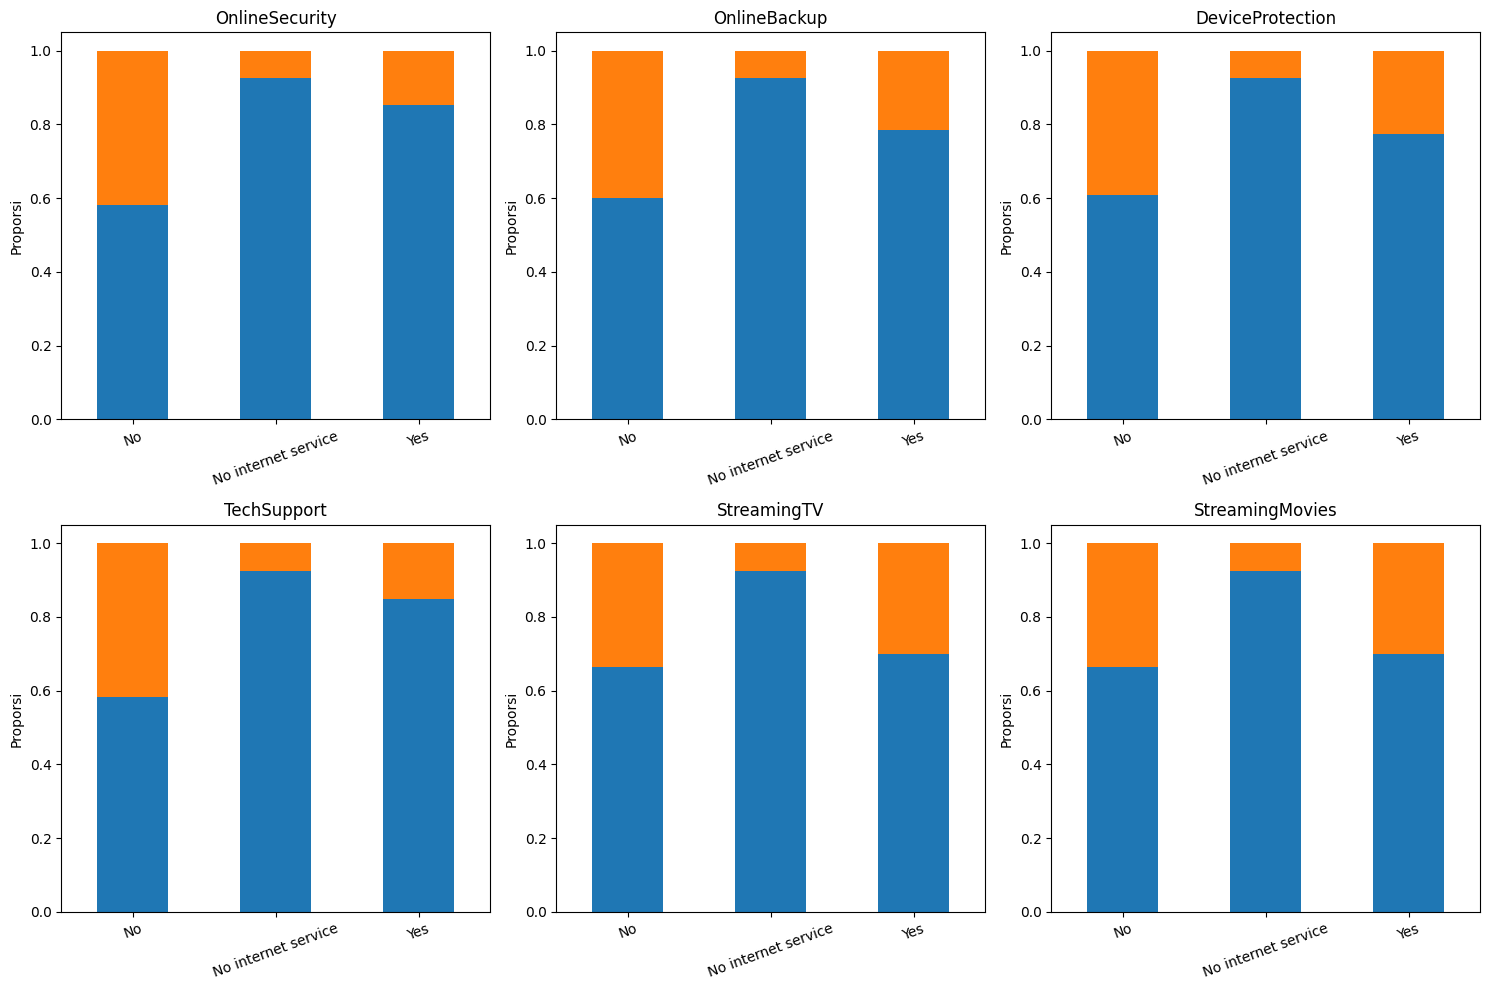

In [10]:
# Visualisasi semua jenis layanan yang ada
fig, axes = plt.subplots(2, 3, figsize=(15,10))
features = ['OnlineSecurity','OnlineBackup','DeviceProtection',
            'TechSupport','StreamingTV','StreamingMovies']

# fitur total services
df['TotalServices'] = df[features].apply(lambda x: (x == 'Yes').sum(), axis=1)

# proporsi Churn untuk tiap fitur
for i, col in enumerate(features):
    row = i // 3
    col_idx = i % 3
    
    ct = pd.crosstab(df[col], df['Churn'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[row, col_idx], legend=False)
    
    axes[row, col_idx].set_title(f'{col}')
    axes[row, col_idx].set_ylabel('Proporsi')
    axes[row, col_idx].set_xlabel('')
    axes[row, col_idx].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('6.Type of service vs Churn.png', dpi=150, bbox_inches='tight')
plt.show()

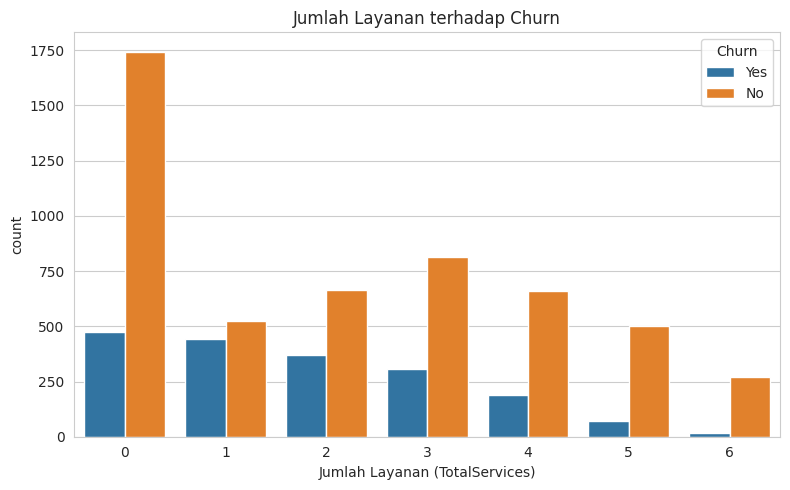

In [11]:
# Analisis Pengaruh Jumlah Layanan terhadap Churn
plt.figure(figsize=(8,5))

df['TotalServices'] = df[features].apply(lambda x: (x == 'Yes').sum(), axis=1)
sns.set_style("whitegrid")
sns.countplot(x='TotalServices', hue='Churn', data=df)

plt.title('Jumlah Layanan terhadap Churn')
plt.xlabel('Jumlah Layanan (TotalServices)')

plt.tight_layout()
plt.show()

# PREPROCESSING

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   str     
 1   gender            7043 non-null   str     
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   str     
 4   Dependents        7043 non-null   str     
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   str     
 7   MultipleLines     7043 non-null   str     
 8   InternetService   7043 non-null   str     
 9   OnlineSecurity    7043 non-null   str     
 10  OnlineBackup      7043 non-null   str     
 11  DeviceProtection  7043 non-null   str     
 12  TechSupport       7043 non-null   str     
 13  StreamingTV       7043 non-null   str     
 14  StreamingMovies   7043 non-null   str     
 15  Contract          7043 non-null   str     
 16  PaperlessBilling  7043 non-null   s

In [13]:
# kita hapus terlebih dahulu featur yang tidak relevan 

# hapus customerID dan tenure_on_year
df.drop(columns=['customerID', 'tenure_on_year'], inplace=True)

# kita ubah TotalCharges karena masih str padahal di dataset dia float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [14]:
# kita buat variabel data frame baru
df_clean = df.copy()
df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalServices
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,2
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,2
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,3
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0


## Cek missing value dan duplicate value

In [15]:
# missing value
df_clean.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
TotalServices        0
dtype: int64

In [16]:
df_clean.dropna(subset=['TotalCharges'], inplace=True)
df_clean.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
TotalServices       0
dtype: int64

In [17]:
# duplicate data
df_clean.duplicated().sum()

np.int64(22)

In [18]:
df_clean.drop_duplicates(inplace=True)
df_clean.duplicated().sum()

np.int64(0)

In [19]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 7010 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   str    
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   str    
 3   Dependents        7010 non-null   str    
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   str    
 6   MultipleLines     7010 non-null   str    
 7   InternetService   7010 non-null   str    
 8   OnlineSecurity    7010 non-null   str    
 9   OnlineBackup      7010 non-null   str    
 10  DeviceProtection  7010 non-null   str    
 11  TechSupport       7010 non-null   str    
 12  StreamingTV       7010 non-null   str    
 13  StreamingMovies   7010 non-null   str    
 14  Contract          7010 non-null   str    
 15  PaperlessBilling  7010 non-null   str    
 16  PaymentMethod     7010 non-null   str    
 17  MonthlyChar

# Feature Encoder

## LabelEncoder

In [20]:
# ubah data "No internet service" menjadi No 
jenis_layanan = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for i in jenis_layanan:
    df_clean[i] = df_clean[i].replace('No internet service', 'No')

# ubah data "No phone service" menjadi "No"
df_clean['MultipleLines'] = df_clean['MultipleLines'].replace('No phone service', 'No')

# ubah data dari gender mejadi 0 dan 1

In [21]:
binary_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'MultipleLines',
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]

le = LabelEncoder()
for i in binary_cols:
    df_clean[i] = le.fit_transform(df_clean[i])

Nilai kategori seperti "No internet service" dan "No phone service" terlebih dahulu diseragamkan menjadi "No" untuk mengurangi redundansi dan memastikan konsistensi data, kemudian seluruh variabel biner (misalnya Yes/No dan Male/Female) ditransformasikan ke representasi numerik (0 dan 1) menggunakan Label Encoding

## Ordinal Encoding

In [22]:
# Mengubah data menjadi numerik yang memiliki urutan menggunakan Ordinal Encoding
df_clean['Contract'] = df_clean['Contract'].map({
    'Month-to-month' : 0,
    'One year' : 1,
    'Two year' : 2
})

## OneHotEncoding

In [23]:
# karena tidk punya urutan nilai data jadi gunakan OneHotEncoding
multi_cols = [
    'InternetService',
    'PaymentMethod'
]

df_clean = pd.get_dummies(df_clean, columns=multi_cols, drop_first=True)

Fitur 'Contract' dikonversi menggunakan ordinal encoding karena memiliki urutan yang jelas berdasarkan tingkat komitmen pelanggan (dari bulanan hingga kontrak jangka panjang), sehingga representasi numerik dapat menangkap hubungan tersebut. Sementara itu, fitur seperti 'InternetService' dan 'PaymentMethod' menggunakan one-hot encoding karena bersifat nominal (tidak memiliki urutan), sehingga setiap kategori direpresentasikan secara independen untuk menghindari asumsi hubungan linear yang tidak sesuai. Penggunaan drop_first=True bertujuan mengurangi redundansi fitur dan mencegah multikolinearitas pada model linear.

In [24]:
df_clean.head(20)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,TotalServices,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,1,29.85,29.85,0,1,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,0,56.95,1889.50,0,2,False,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,1,53.85,108.15,1,2,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,0,42.30,1840.75,0,3,False,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,1,70.70,151.65,1,0,True,False,False,True,False
5,0,0,0,0,8,1,1,0,0,1,...,1,99.65,820.50,1,3,True,False,False,True,False
6,1,0,0,1,22,1,1,0,1,0,...,1,89.10,1949.40,0,2,True,False,True,False,False
7,0,0,0,0,10,0,0,1,0,0,...,0,29.75,301.90,0,1,False,False,False,False,True
8,0,0,1,0,28,1,1,0,0,1,...,1,104.80,3046.05,1,4,True,False,False,True,False
9,1,0,0,1,62,1,0,1,1,0,...,0,56.15,3487.95,0,2,False,False,False,False,False


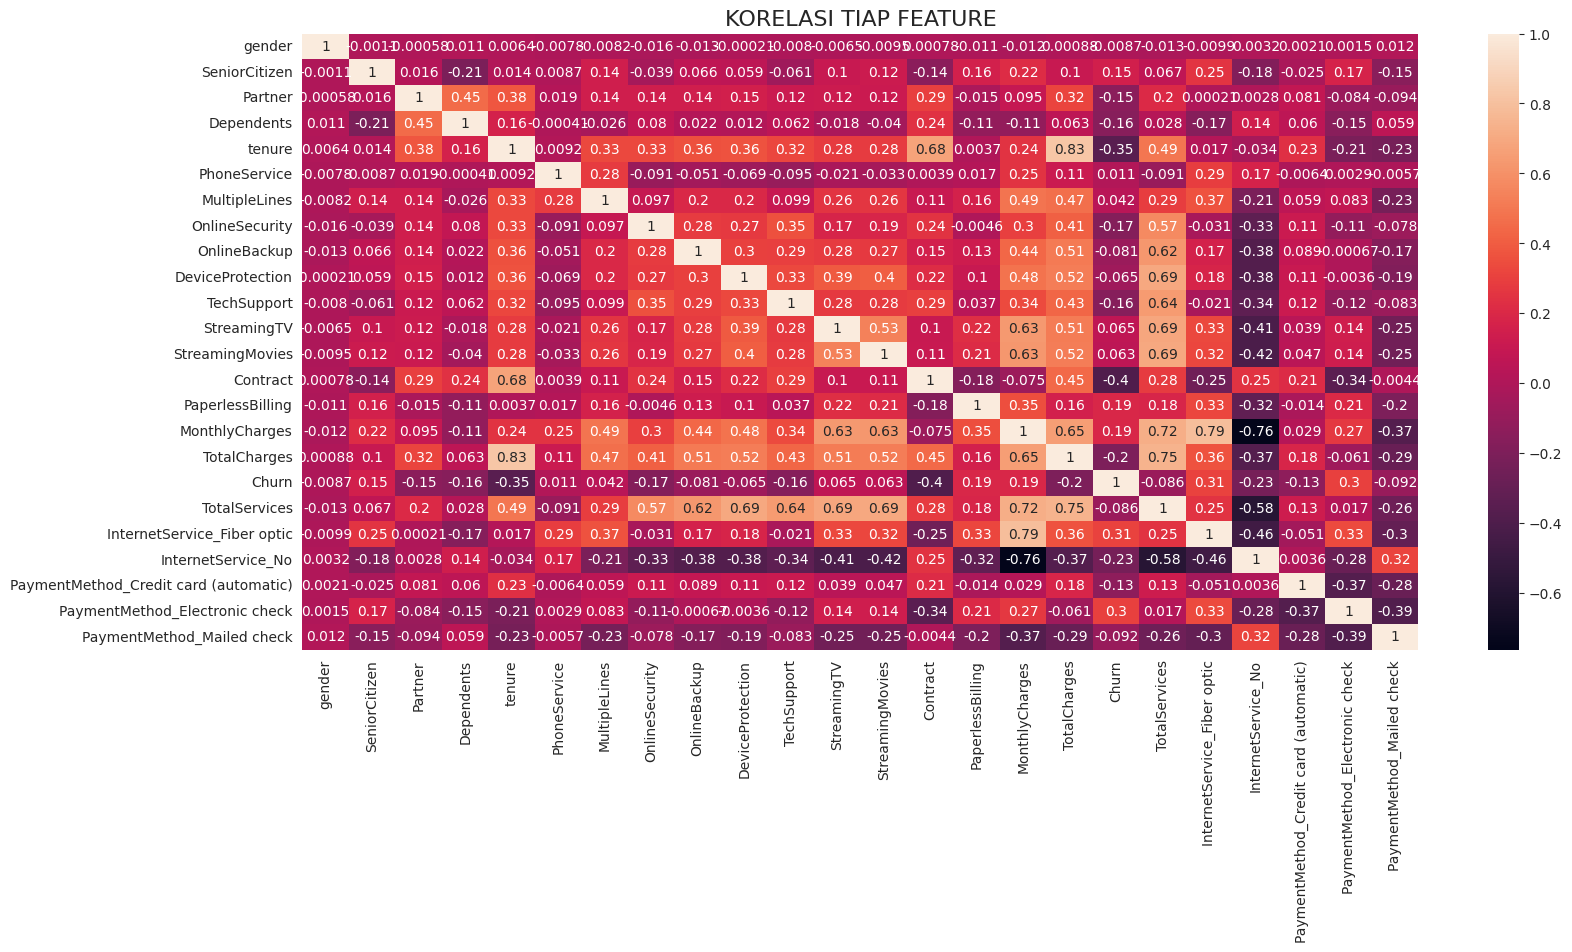

In [25]:
# Korelasi dari data yang sudah bersih
plt.figure(figsize=(18,8))

heat_cor = df_clean.corr()
sns.heatmap(data=heat_cor, annot=True)

plt.title('KORELASI TIAP FEATURE',fontsize=16)
plt.savefig('7.Heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Split data

In [26]:
X = df_clean.drop(columns='Churn')
y = df_clean['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [27]:
print(list(X_train.columns))
print(y_train.name)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'TotalServices', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
Churn


# Normalisasi

In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE 

In [29]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Sebelum SMOTE")
print(y_train.value_counts())
print("Setelah SMOTE")
print(y_train_smote.value_counts())

Sebelum SMOTE
Churn
0    4122
1    1486
Name: count, dtype: int64
Setelah SMOTE
Churn
0    4122
1    4122
Name: count, dtype: int64


Disini pada feature target itu mengalami imbalanced data, jadi digunaakn teknik SMOTE utk mengatasi imbalanced data tersebut agar dataya sama rata

# LightGBM modeling

In [30]:
lgbm_model = LGBMClassifier(
    n_estimators=100,
    max_depth=12,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

lgbm_model.fit(
    X_train_smote, y_train_smote
)

[LightGBM] [Info] Number of positive: 4122, number of negative: 4122
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000629 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2526
[LightGBM] [Info] Number of data points in the train set: 8244, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,12
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [31]:
# evaluasi modelnya
y_pred = lgbm_model.predict(X_test_scaled)

conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(conf_matrix)
print(class_report)
print(f'Akurasi model: {accuracy:.3f}')

[[872 159]
 [135 236]]
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1031
           1       0.60      0.64      0.62       371

    accuracy                           0.79      1402
   macro avg       0.73      0.74      0.74      1402
weighted avg       0.79      0.79      0.79      1402

Akurasi model: 0.790


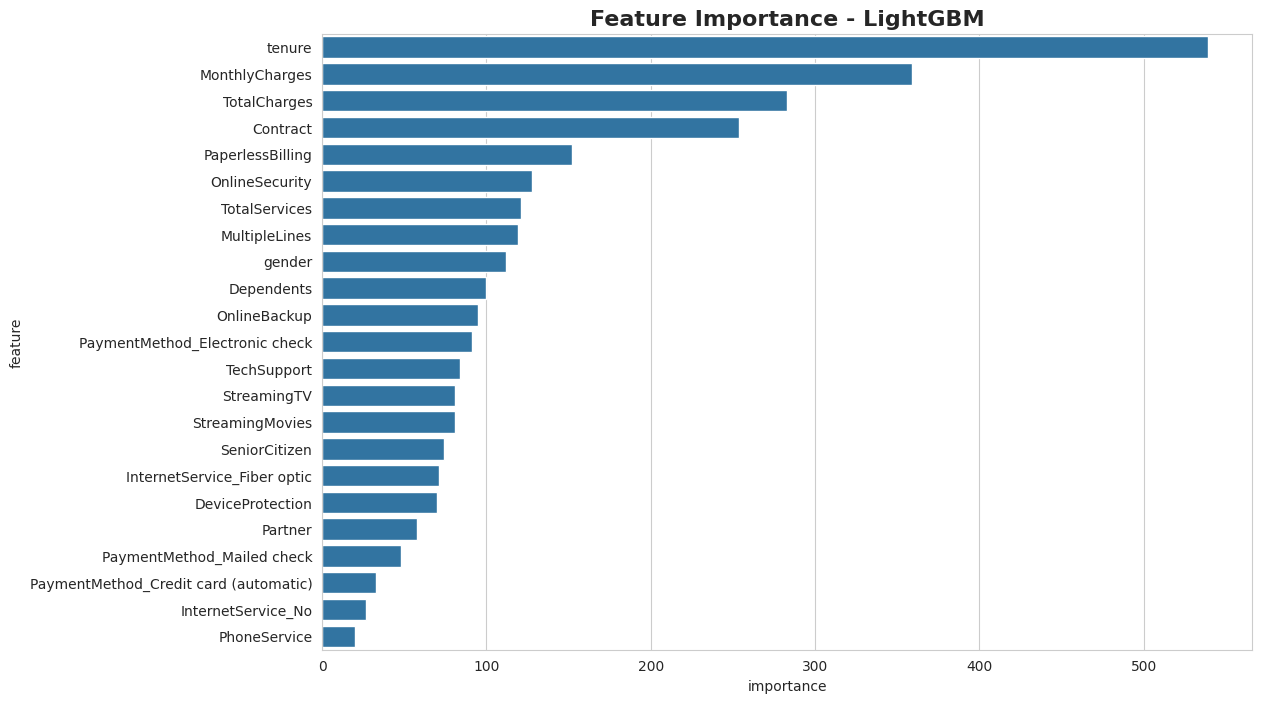

In [32]:
importance = pd.DataFrame({
    'feature' : X_train.columns,
    'importance' : lgbm_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(data=importance, x='importance', y='feature')

plt.title('Feature Importance - LightGBM', fontsize=16, fontweight='bold')
plt.savefig('8.LightGBM_Feature Importance.png', dpi=150, bbox_inches='tight')
plt.show()

# RandomForestClassifier Modeling

In [33]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    n_jobs=-1
)

rf_model.fit(
    X_train_smote, y_train_smote
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [34]:
# evaluasi modelnya
y_pred = rf_model.predict(X_test_scaled)

conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(conf_matrix)
print(class_report)
print(f'Akurasi model: {accuracy:.3f}')

[[852 179]
 [123 248]]
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1031
           1       0.58      0.67      0.62       371

    accuracy                           0.78      1402
   macro avg       0.73      0.75      0.74      1402
weighted avg       0.80      0.78      0.79      1402

Akurasi model: 0.785


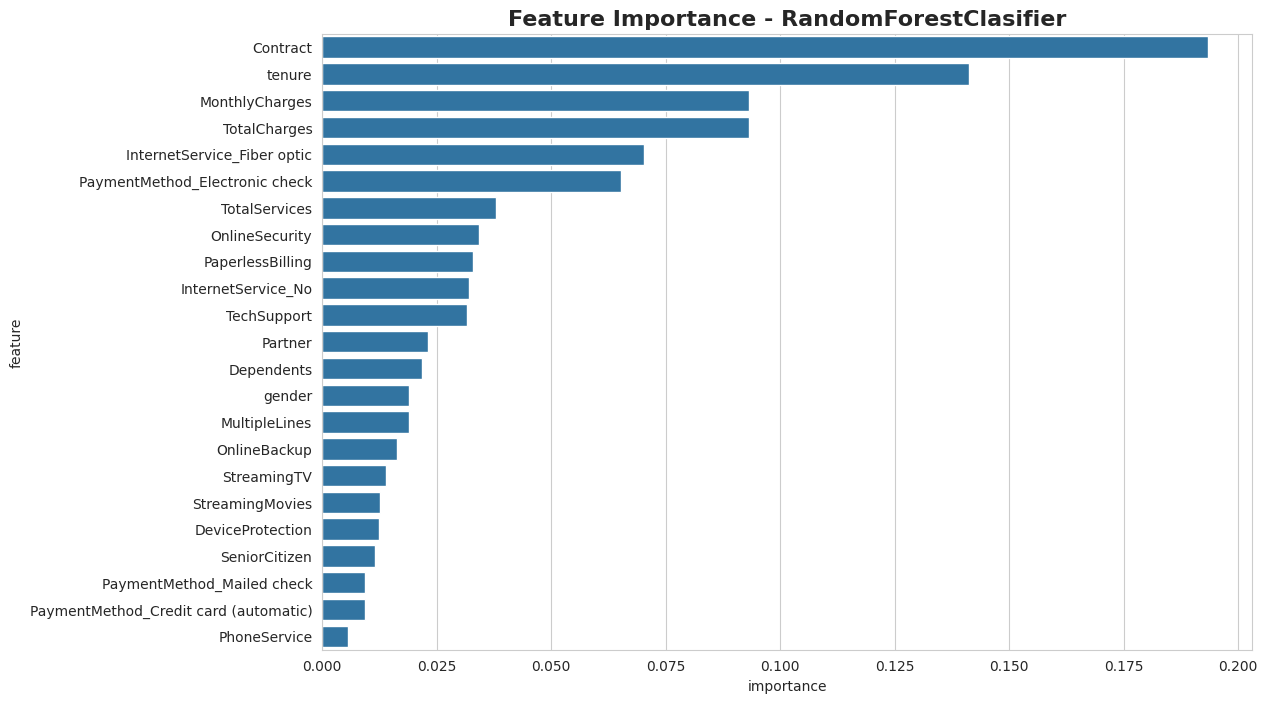

In [35]:
importance = pd.DataFrame({
    'feature' : X_train.columns,
    'importance' : rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(data=importance, x='importance', y='feature')

plt.title('Feature Importance - RandomForestClasifier', fontsize=16, fontweight='bold')
plt.savefig('9.RandomForest_Feature Importance.png', dpi=150, bbox_inches='tight')
plt.show()

# XGBoost Model

In [36]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train_smote, y_train_smote
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [37]:
# evaluasi modelnya
y_pred = xgb_model.predict(X_test_scaled)

conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(conf_matrix)
print(class_report)
print(f'Akurasi model: {accuracy:.3f}')

[[877 154]
 [175 196]]
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      1031
           1       0.56      0.53      0.54       371

    accuracy                           0.77      1402
   macro avg       0.70      0.69      0.69      1402
weighted avg       0.76      0.77      0.76      1402

Akurasi model: 0.765


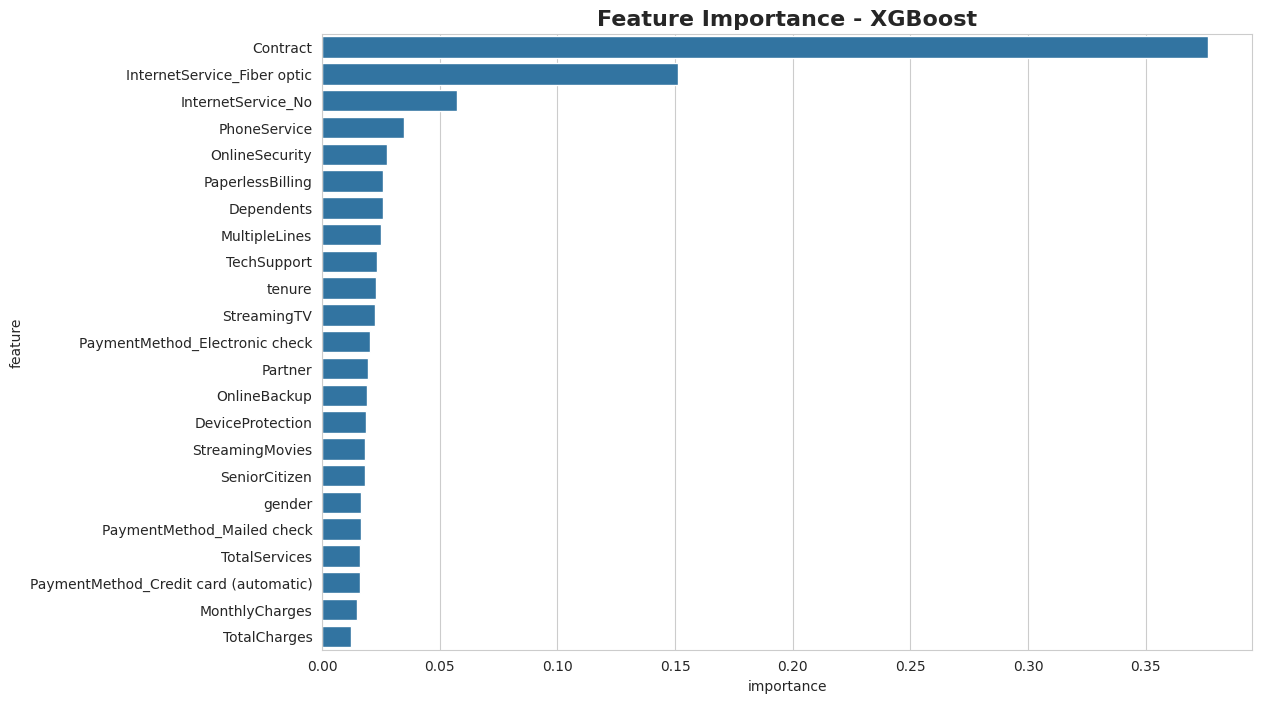

In [38]:
importance = pd.DataFrame({
    'feature' : X_train.columns,
    'importance' : xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(data=importance, x='importance', y='feature')

plt.title('Feature Importance - XGBoost', fontsize=16, fontweight='bold')
plt.savefig('10.XGBoost_Feature Importance.png', dpi=150, bbox_inches='tight')
plt.show()

# LogisticRegression Model

In [39]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
   X_train_smote, y_train_smote 
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [40]:
y_pred = lr_model.predict(X_test_scaled)

In [41]:
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(conf_matrix)
print(class_report)
print(f'Akurasi model: {accuracy:.3f}')

[[757 274]
 [ 85 286]]
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1031
           1       0.51      0.77      0.61       371

    accuracy                           0.74      1402
   macro avg       0.70      0.75      0.71      1402
weighted avg       0.80      0.74      0.76      1402

Akurasi model: 0.744


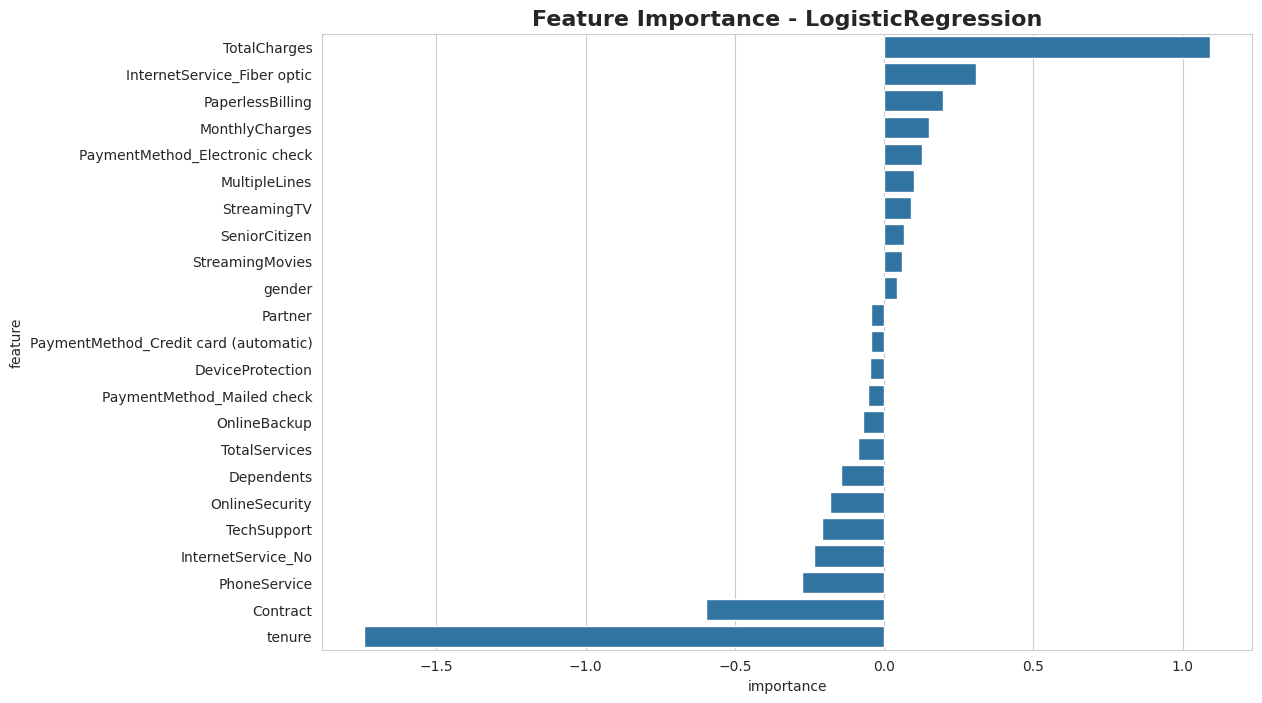

In [42]:
importance = pd.DataFrame({
    'feature' : X_train.columns,
    'importance' : lr_model.coef_[0]
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(data=importance, x='importance', y='feature')

plt.title('Feature Importance - LogisticRegression', fontsize=16, fontweight='bold')
plt.savefig('11.LogisticRegression_Feature Importance.png', dpi=150, bbox_inches='tight')
plt.show()

- Hasil evaluasi menunjukkan bahwa setiap model memiliki karakteristik performa yang berbeda dalam  memprediksi churn. Model LightGBM menghasilkan akurasi tertinggi sebesar 0.790 dengan performa yang relatif seimbang antara precision dan recall, sehingga dapat dikatakan sebagai model yang paling stabil secara keseluruhan. 

- Random Forest menunjukkan performa yang sedikit di bawah LightGBM dengan akurasi 0.785, namun memiliki keseimbangan yang cukup baik dalam mendeteksi kelas churn, ditunjukkan oleh nilai recall sebesar 0.67.

- Sementara itu, Logistic Regression memiliki kemampuan terbaik dalam mendeteksi pelanggan churn dengan nilai recall tertinggi sebesar 0.77, namun kelemahannya terletak pada banyaknya false positive sehingga precision menjadi rendah. 

- Di sisi lain, XGBoost memberikan performa yang paling rendah dalam mendeteksi churn dengan recall sebesar 0.53, yang menunjukkan bahwa model ini kurang efektif dalam menangkap pelanggan yang benar-benar akan churn.

Secara keseluruhan, terdapat trade-off yang jelas antara kemampuan mendeteksi churn dan tingkat kesalahan prediksi. Jika tujuan utama adalah meminimalkan kehilangan pelanggan (meningkatkan recall), maka Logistic Regression menjadi pilihan yang tepat. Namun, jika menginginkan keseimbangan performa secara menyeluruh, maka LightGBM atau Random Forest lebih direkomendasikan, dengan LightGBM sebagai kandidat terbaik karena memberikan kombinasi akurasi dan stabilitas yang paling baik.